## 生成人脸GAN

代码改写自： 电子工业出版社的《深度学习框架PyTorch：入门与实践》第七章的配套代码

用于展示生成人脸的展示，原文用的是卡通人像。与李宏毅课程中的一致，目前广泛使用的知乎用户[何之源](https://www.zhihu.com/people/he-zhi-yuan-16)爬取的数据（275M，约5万多张图片）已经不容易下下载到了，可以自己写爬虫爬取[Danbooru](http://safebooru.donmai.us/)或者[konachan](http://konachan.net/)。
这里，我们用的是celebA对齐之后的头像,请把所有clip之后的人脸图片直接存放在data/face/目录下即可。

![face sample](generated_499.png)

In [1]:
import os
import ipdb
import imageio.v2 as imageio
import torch as t
import torchvision as tv

In [2]:
import tqdm
from torchnet.meter import AverageValueMeter

In [18]:
# 配置参数
image_size = 96  # 图片尺寸

nz = 100  # 噪声维度
ngf = 64  # 生成器feature map数
ndf = 64  # 判别器feature map数

save_path = 'imgs/'  # 生成图片保存路径

In [4]:
# 只测试不训练
gen_img = 'result.png'
# 从512张生成的图片中保存最好的64张
gen_num = 64
gen_search_num = 500
gen_mean = 0  # 噪声的均值
gen_std = 1  # 噪声的方差

### 1. 定义网络结构

In [5]:
from torch import nn

In [6]:
class NetG(nn.Module):    # 生成器

    def __init__(self,):
        super(NetG, self).__init__()
        
        self.main = nn.Sequential(
            # 输入是一个nz维度的噪声，我们可以认为它是一个1*1*nz的feature map
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # 上一步的输出形状：(ngf*8) x 4 x 4

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # 上一步的输出形状： (ngf*4) x 8 x 8

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # 上一步的输出形状： (ngf*2) x 16 x 16

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # 上一步的输出形状：(ngf) x 32 x 32

            nn.ConvTranspose2d(ngf, 3, 5, 3, 1, bias=False),
            nn.Tanh()  # 输出范围 -1~1 故而采用Tanh
            # 输出形状：3 x 96 x 96
        )

    def forward(self, input):
        return self.main(input)

In [7]:
class NetD(nn.Module):    # 判别器

    def __init__(self,):
        super(NetD, self).__init__()
        self.main = nn.Sequential(
            # 输入 3 x 96 x 96
            nn.Conv2d(3, ndf, 5, 3, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 输出 (ndf) x 32 x 32

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 输出 (ndf*2) x 16 x 16

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 输出 (ndf*4) x 8 x 8

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # 输出 (ndf*8) x 4 x 4

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # 输出一个数(概率)
        )

    def forward(self, input):
        return self.main(input).view(-1)

### 2. 使用：generate image test

可下载预训练好的生成模型[netg_cartoon200.pth](http://pytorch-1252820389.cosbj.myqcloud.com/netg_200.pth)，下载预训练的判别模型[netd_cartoon200.pth](http://pytorch-1252820389.cosbj.myqcloud.com/netd_200.pth)

In [49]:
netd_path = 'netd_cartoon200.pth' #预训练模型
netg_path = 'netg_carton200.pth'

In [50]:
device = t.device('cuda:1') if t.cuda.is_available() else t.device('cpu')

In [51]:
netg = NetG().to(device)

In [52]:
map_location = lambda storage, loc: storage
netg.load_state_dict(t.load(netg_path, map_location=map_location))

<All keys matched successfully>

In [53]:
noises = t.randn(gen_search_num, nz, 1, 1).normal_(gen_mean, gen_std).to(device)

In [54]:
# 生成图片
fake_img = netg(noises)

### 3. 计算图片在判别器的得分，并保存结果

In [55]:
netd = NetD().to(device)
netd.load_state_dict(t.load(netd_path, map_location=map_location))

<All keys matched successfully>

In [56]:
scores = netd(fake_img).detach()

In [57]:
# 挑选最好的某几张
indexs = scores.topk(gen_num)[1]
result = []
for ii in indexs:
    result.append(fake_img.data[ii])

In [58]:
 # 保存图片便于查看
tv.utils.save_image(t.stack(result), 'generated200.png', normalize=True, range=(-1, 1))   

### 4. 进阶：对抗训练

In [24]:
transforms = tv.transforms.Compose([
        tv.transforms.Resize(image_size),
        tv.transforms.CenterCrop(image_size),
        tv.transforms.ToTensor(),
        tv.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

#### A. 直接用文件夹的方式定义数据集，需要的时候读入，节省内存

In [25]:
dataset = tv.datasets.ImageFolder('../dataset/img_align_celeba/', transform=transforms)

#### B. 如果内存足够，不妨先全部读入内存中作为缓存，代价是需要自定义数据类

In [1]:
from PIL import Image
from torch.utils.data import Dataset

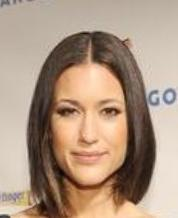

In [2]:
image = Image.open(r'../dataset/img_align_celeba/131225.jpg')
image

In [28]:
# 加载数据集，自己重写DataSet类
class face_celeba_dataset(Dataset):
    # image_dir为数据目录，label_file，为标签文件
    def __init__(self, image_dir, transform=None):
        super(face_celeba_dataset, self).__init__()    # 添加对父类的初始化
        self.image_dir = image_dir         # 图像文件所在路径
        self.transform = transform         # 数据转换操作
        total_images = 200000   # 想要加入的所有图片数量， celeba的总数是202,599
        count = 0
        self.images = [i for i in range(0, total_images)]

        for root, dirs, files in os.walk(image_dir):
            for file in files:
                if (file[-4:] == '.jpg'):
                    img = Image.open(image_dir + '/' + file)
                    
                if self.transform:
                    img = self.transform(img)
                self.images[count] = img
                count = count + 1
                
                if (count%2000 == 0):
                    print("images loading  ...... #", count)
                pass
            
                # stop when total_images reached
                if (count == total_images):
                    break
                pass            
            pass
        pass
    
    
    # 加载每一项数据
    def __getitem__(self, index):        
        return self.images[index]
    
    # 数据集大小
    def __len__(self):
        return (len(self.images))

In [29]:
dataset = face_celeba_dataset('face_celebA/face/', transforms)

images loading  ...... # 2000
images loading  ...... # 4000
images loading  ...... # 6000
images loading  ...... # 8000
images loading  ...... # 10000
images loading  ...... # 12000
images loading  ...... # 14000
images loading  ...... # 16000
images loading  ...... # 18000
images loading  ...... # 20000
images loading  ...... # 22000
images loading  ...... # 24000
images loading  ...... # 26000
images loading  ...... # 28000
images loading  ...... # 30000
images loading  ...... # 32000
images loading  ...... # 34000
images loading  ...... # 36000
images loading  ...... # 38000
images loading  ...... # 40000
images loading  ...... # 42000
images loading  ...... # 44000
images loading  ...... # 46000
images loading  ...... # 48000
images loading  ...... # 50000
images loading  ...... # 52000
images loading  ...... # 54000
images loading  ...... # 56000
images loading  ...... # 58000
images loading  ...... # 60000
images loading  ...... # 62000
images loading  ...... # 64000
images loadi

#### 和批大小有关的变量

In [59]:
batch_size = 5000

In [60]:
dataloader = t.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=5, drop_last=True )

In [61]:
# 真图片label为1，假图片label为0
# noises为生成网络的输入
true_labels = t.ones(batch_size).to(device)
fake_labels = t.zeros(batch_size).to(device)
fix_noises = t.randn(batch_size, nz, 1, 1).to(device)
noises = t.randn(batch_size, nz, 1, 1).to(device)

#### 载入模型

In [62]:
netg, netd = NetG(), NetD()
map_location = lambda storage, loc: storage
if netd_path:
    netd.load_state_dict(t.load(netd_path, map_location=map_location))
if netg_path:
    netg.load_state_dict(t.load(netg_path, map_location=map_location))
netd.to(device)
netg.to(device)

NetG(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(5, 5), stride=(3, 3), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [33]:
# 定义优化器和损失
lr1 = 1e-5  # 生成器的学习率
lr2 = 2e-5  # 判别器的学习率
beta1 = 0.5  # Adam优化器的beta1参数
optimizer_g = t.optim.Adam(netg.parameters(), lr1, betas=(beta1, 0.999))
optimizer_d = t.optim.Adam(netd.parameters(), lr2, betas=(beta1, 0.999))
criterion = t.nn.BCELoss().to(device)

In [63]:
max_epoch = 1000
plot_every = 20  # 每间隔20 batch，visdom画图一次
d_every = 1  # 每1个batch训练一次判别器
g_every = 2  # 每5个batch训练一次生成器
save_every = 100  # 50个epoch保存一次模型

开始训练

In [64]:
%%time

errord_meter = AverageValueMeter()
errorg_meter = AverageValueMeter()
epochs = range(max_epoch)
for epoch in iter(epochs):
    for ii, img in tqdm.tqdm(enumerate(dataloader)):
        real_img = img.to(device)   # try to do the batch normalization
          # one should be care of the transformers

        if ii % d_every == 0:
            # 训练判别器
            optimizer_d.zero_grad()
            ## 尽可能的把真图片判别为正确
            output = netd(real_img)
            error_d_real = criterion(output, true_labels)
            error_d_real.backward()

            ## 尽可能把假图片判别为错误
            noises.data.copy_(t.randn(batch_size, nz, 1, 1))
            fake_img = netg(noises).detach()  # 根据噪声生成假图
            output = netd(fake_img)
            error_d_fake = criterion(output, fake_labels)
            error_d_fake.backward()
            optimizer_d.step()

            error_d = error_d_fake + error_d_real

            errord_meter.add(error_d.item())

        if ii % g_every == 0:
            # 训练生成器
            optimizer_g.zero_grad()
            noises.data.copy_(t.randn(batch_size,nz, 1, 1))
            fake_img = netg(noises)
            output = netd(fake_img)
            error_g = criterion(output, true_labels)
            error_g.backward()
            optimizer_g.step()
            errorg_meter.add(error_g.item())
            

    if (epoch+1) % save_every == 0:
        # 保存模型、图片        
        fix_fake_imgs = netg(fix_noises)      
        tv.utils.save_image(fix_fake_imgs.data[:64], '%s/%s.png' % (save_path, epoch+1), normalize=True,range=(-1, 1))
        t.save(netd.state_dict(), 'checkpoints/netd_%s.pth' % epoch+1)
        t.save(netg.state_dict(), 'checkpoints/netg_%s.pth' % epoch+1)
        errord_meter.reset()
        errorg_meter.reset()

40it [01:55,  2.89s/it]
40it [01:55,  2.90s/it]
40it [01:55,  2.89s/it]
40it [01:55,  2.90s/it]
40it [01:55,  2.90s/it]
40it [01:55,  2.89s/it]
40it [01:55,  2.90s/it]
40it [01:58,  2.95s/it]
40it [01:55,  2.89s/it]
40it [01:55,  2.90s/it]
40it [01:55,  2.89s/it]
40it [01:55,  2.89s/it]
40it [01:56,  2.90s/it]
40it [01:56,  2.90s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.92s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:57,  2.94s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.90s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:55,  2.89s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.91s/it]
40it [01:56,  2.

CPU times: user 1d 5h 50min 4s, sys: 3h 34min 32s, total: 1d 9h 24min 36s
Wall time: 1d 10h 10min 11s


#### Result with 1080ti:
1009458@imath with xeon 2680 v2 cpu & 1080ti, costs 395it with batchsize=512 [01:30,  4.36it/s], totally around 200,000 images.